### Model inspired by:

- [1] Offshore Pipelaying Dynamics. Gullik Anthon Jensen
- [2] A nonlinear PDE formulation for offshore vessel pipeline installation. Gullik A. Jensen et al
- [3] Modeling and Control of Offshore Pipelay Operations Based on a Finite Strain Pipe Model. Gullik A. Jensen

### Implementation aspects:

- The model can be applied to normal dynamic pipelay condition as a rough estimate

In [1]:
import numpy as np
import inspect
import matplotlib.pyplot as plt
import scipy
from datetime import datetime
from scipy.optimize import root
from scipy.integrate import solve_ivp
from scipy import interpolate
import plotly.graph_objects as go
from scipy.interpolate import interp1d
from scipy import integrate
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.spatial.transform import Rotation as Rot

In [2]:
# import diffeqpy
# from diffeqpy import de
# from juliacall import Main as jl

### Input data:

In [3]:
mp = 179.7      #  (submerged pipe weight) [kg/m]
N = 25    # number of modelling nodes

In [4]:
qw = 1025 # Water density [kg/m3]
d0 = 0.508 # Outer diameter of pipe, [m]
dI= (508-33*2)/1000 # Inner diameter of pipe, [m]

In [5]:
# Underwater current: 
dv1_curr = 0
dv2_curr = 0
dv3_curr = 0

In [6]:
Fx_0 = 1515*1000
Fy_0 = 0.8*Fx_0
LTD = 209

In [7]:
E = 207e9
G = 79.3e9
nu0 = 0.3

In [8]:
TPL =  LTD/(N-1)

In [9]:
# vessel

In [10]:
mn = 39_989_000 # mass of the vessel, [kg]
L = 168 
Xg = 78 # [m]
Yg = 10
Zg = 1

In [11]:
# Fossen book p.181
def vessel_inertia_moment(mn, Xg, L):
    r = 0.25*L
    Ir = mn*r**2
    Iz = mn*Xg**2 + Ir
    return Iz

In [12]:
In = vessel_inertia_moment(mn, Xg, L)

In [13]:
draft = 6

In [14]:
# integration parameters
tspan = (0.,20.)

In [15]:
A_wp = 6000

### Main functions:

In [16]:
A = np.pi * ((d0/2)**2 - (dI/2)**2)

In [17]:
m = (dI/2)/ (d0/2)
m2 = m**2
k_shear = (6.0 * (1.0 + nu0) * (1.0 + m2)**2) / (
    (7.0 + 6.0 * nu0) * (1.0 + m2)**2 + (20.0 + 12.0 * nu0) * m2)

In [18]:
A2 = k_shear * A
A3 = k_shear * A

In [19]:
J = (np.pi / 2.0) * ((d0/2)**4 - (dI/2)**4)

In [20]:
J1 = J

In [21]:
J2 = (np.pi / 64) * (d0**4 - dI**4)
J3 = J2

In [22]:
I1=(1/2)*mp*((d0/2)**2+(dI/2)**2)*TPL

In [23]:
I1

88.69547616875

In [24]:
I2 = (1/12)*mp*(3*(d0/2)**2+3*(dI/2)**2)*TPL
I3 = I2

In [25]:
I3

44.347738084374996

In [26]:
def Ret_e_t(φ, θ, ψ):                       # scalars or (N,) arrays, as before
    r = np.stack(np.broadcast_arrays(φ, θ, ψ), axis=-1)
    return Rot.from_rotvec(r.reshape(-1, 3)).as_matrix().reshape(r.shape[:-1] + (3, 3))

def Πe(φ, θ, ψ):                            # omega_spatial = Πe @ rdot
    r = np.array([φ, θ, ψ], float); a = np.linalg.norm(r); K = S(*r)
    if a < 1e-4: c1, c2 = 0.5 - a**2/24, 1/6 - a**2/120
    else:        c1, c2 = (1 - np.cos(a))/a**2, (a - np.sin(a))/a**3
    return np.eye(3) + c1*K + c2*K@K

def dΠ(φ, θ, ψ, dφ, dθ, dψ):                # d/dt of Πe, central difference
    r = np.array([φ, θ, ψ], float); dr = np.array([dφ, dθ, dψ], float)
    eps = 1e-6/max(1.0, np.linalg.norm(dr))
    return (Πe(*(r + eps*dr)) - Πe(*(r - eps*dr)))/(2*eps)

In [27]:
# def Πe(φ, θ, ψ):
#     max_safe_angle = np.radians(89.9) 
#     φ_clamped = np.clip(φ, -max_safe_angle, max_safe_angle)
#     return np.array([
#         [ np.cos(θ), 0, np.cos(φ_clamped) * np.sin(θ)], 
#         [         0, 1, -np.sin(φ_clamped)], 
#         [-np.sin(θ), 0, np.cos(φ_clamped) * np.cos(θ)]
#     ])        

In [28]:
# def Ret_e_t(φ, θ, ψ):
#     safety_margin = 0.001 
#     θ = np.clip(θ, -np.pi/2 + safety_margin, np.pi/2 - safety_margin)
    
#     is_array = isinstance(φ, np.ndarray)
#     N = len(φ) if is_array else 1

#     cos_f, sin_f = np.cos(φ), np.sin(φ)
#     cos_t, sin_t = np.cos(θ), np.sin(θ)
#     cos_p, sin_p = np.cos(ψ), np.sin(ψ)

#     if is_array:
#         C = np.zeros((N, 3, 3))
#     else:
#         C = np.zeros((3, 3))

#     C[..., 0, 0] = cos_t * cos_p + sin_t * sin_f * sin_p
#     C[..., 0, 1] = -cos_t * sin_p + sin_t * sin_f * cos_p
#     C[..., 0, 2] = sin_t * cos_f

#     C[..., 1, 0] = cos_f * sin_p
#     C[..., 1, 1] = cos_f * cos_p
#     C[..., 1, 2] = -sin_f

#     C[..., 2, 0] = -sin_t * cos_p + cos_t * sin_f * sin_p
#     C[..., 2, 1] = sin_t * sin_p + cos_t * sin_f * cos_p
#     C[..., 2, 2] = cos_t * cos_f

#     return C

In [29]:
diag_J_t_rho = np.array([I1, I2, I3])      
J_t_rho = np.diag(diag_J_t_rho)

In [30]:
diag_CT = np.array([E*A, G*A2, G*A3])
CT=np.diag(diag_CT) 

In [31]:
diag_CR = np.array([G*J, E*J2, E*J3]) 
CR=np.diag(diag_CR) 

In [32]:
diag_DT = 1.5*np.array([1, 1, 1])
DT=np.diag(diag_DT)

In [33]:
diag_DR = 1.5*np.array([1, 1, 1])  
DR=np.diag(diag_DR)

In [34]:
def I_e_rho(φ,θ,ψ):
    return Ret_e_t(φ,θ,ψ) @ J_t_rho @ Ret_e_t(φ,θ,ψ).T

In [35]:
def phi(x,y,z): return np.array([x,y,z]) 
def theta(φ,θ,ψ): return np.array([φ,θ,ψ]) 

In [36]:
def d_s_theta(φ1,θ1,ψ1,φ2,θ2,ψ2,h):
    return  1/h*(theta(φ2,θ2,ψ2) - theta(φ1,θ1,ψ1)) 
    # return rprime / np.linalg.norm(rprime)

In [37]:
def S(a1, a2, a3 ):
    return np.array([[0, -a3, a2 ],
                         [a3, 0, -a1],
                        [-a2, a1, 0]])

In [38]:
def d_s_phi(x1,y1,z1,x2,y2,z2, h):
    return 1/h*(phi(x2,y2,z2)-phi(x1,y1,z1))
    # return rprime / np.linalg.norm(rprime)

In [39]:
# def ne(x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, h):
#     res = Ret_e_t(φ1,θ1,ψ1) @ CT @ Ret_e_t(φ1,θ1,ψ1).T @ (
#         d_s_phi(x1,y1,z1,x2,y2,z2,h).flatten() 
#         - Ret_e_t(φ1,θ1,ψ1) @ np.array([1,0,0])
#     )
#     return res.flatten()    

In [40]:
# def me(φ1, θ1, ψ1, φ2, θ2, ψ2, h):
#     kappa_e = Πe(φ1, θ1, ψ1) @ d_s_theta(φ1, θ1, ψ1, φ2, θ2, ψ2, h)
#     return Ret_e_t(φ1, θ1, ψ1) @ CR @ kappa_e   

In [41]:
def ne(x1,y1,z1,φ1,θ1,ψ1,x2,y2,z2,φ2,θ2,ψ2,h):
    R = Ret_e_t(0.5*(φ1+φ2), 0.5*(θ1+θ2), 0.5*(ψ1+ψ2))
    return (R @ CT @ R.T @ (d_s_phi(x1,y1,z1,x2,y2,z2,h).flatten() - R @ np.array([1,0,0]))).flatten()

def me(φ1,θ1,ψ1,φ2,θ2,ψ2,h):
    φm, θm, ψm = 0.5*(φ1+φ2), 0.5*(θ1+θ2), 0.5*(ψ1+ψ2)
    κ = Πe(φm,θm,ψm) @ d_s_theta(φ1,θ1,ψ1,φ2,θ2,ψ2,h)
    return Ret_e_t(φm,θm,ψm) @ CR @ κ

In [42]:
# def dΠ(φ, θ, ψ, dφ, dθ, dψ):
#     max_safe_angle = np.radians(89.9) 
#     φ_clamped = np.clip(φ, -max_safe_angle, max_safe_angle)
    
#     return np.array([
#         [-np.sin(θ)*dθ, 0, -np.sin(φ_clamped)*dφ*np.sin(θ) + np.cos(φ_clamped)*np.cos(θ)*dθ],
#         [            0, 0, -np.cos(φ_clamped)*dφ],
#         [-np.cos(θ)*dθ, 0, -np.sin(φ_clamped)*dφ*np.cos(θ) - np.cos(φ_clamped)*np.sin(θ)*dθ]
#     ])    

In [43]:
fe_g = np.array([0,0, -mp*TPL*9.81])

In [44]:
# def f_t_d(dx,dy,dz): 
    
#     vr1 = dx - dv1_curr
#     vr2 = dy - dv2_curr  
#     vr3 = dz - dv3_curr
#     A = np.array([np.abs(vr1) * vr1,
#                   np.sqrt(vr2**2 + vr3**2) * vr2,
#                  np.sqrt(vr2**2 + vr3**2) * vr3])
#     return 0.5 * d0 * qw * (DT@ A)

def f_t_d(dx, dy, dz): 
    vr1 = dx - dv1_curr
    vr2 = dy - dv2_curr  
    vr3 = dz - dv3_curr
    
    v_cross_mag = np.sqrt(vr2**2 + vr3**2)
   
    if v_cross_mag > 1e-10:
        
        A = np.array([
            np.abs(vr1) * vr1,
            v_cross_mag * vr2,
            v_cross_mag * vr3
        ])
    else:
        A = np.array([np.abs(vr1) * vr1, 0.0, 0.0])
        
    return 0.5 * d0 * qw * (DT @ A)


In [45]:
def sigma(x,y,z):
    e3 = np.array([0,0,1])
    
    k = -(phi(x,y,z) @ e3)+d0/2
    
    fe_g2 = np.linalg.norm(fe_g, ord=2)
   
    if k<0:
        k0=0
    elif 0<=k<=d0/20:
        k0=(fe_g2*10*k**2)/((d0/8-d0/40)*(d0))
    else:
        k0=(fe_g2*(k-d0/40))/(d0/8-d0/40)
            
    result = - k0 * e3 
   
    return result  

In [46]:
def Hmtrx(r):
    r = np.asarray(r, dtype=float).flatten()
    H = np.eye(6)
    H[0:3, 3:6] = S(*r).T
    return H

In [47]:
def compute_damping(M_CG, G_CG, rCG, T_x, T_y, T_n):
 
    beta_z = 0.995      
    beta_phi = 0.995    
    beta_theta = 0.995
 
   
    zeta_z = np.sqrt(1 - beta_z ** 2)
    zeta_phi = np.sqrt(1 - beta_phi ** 2)
    zeta_theta = np.sqrt(1 - beta_theta ** 2)
 
    D_CG11 = M_CG[0, 0] / T_x
    D_CG22 = M_CG[1, 1] / T_y
    D_CG66 = M_CG[5, 5] / T_n
 
   
    k_z = G_CG[2, 2] if G_CG.ndim == 2 else G_CG[2]
    k_phi = G_CG[3, 3] if G_CG.ndim == 2 else G_CG[3]
    k_theta = G_CG[4, 4] if G_CG.ndim == 2 else G_CG[4]

    D_CG33 = 2 * zeta_z * np.sqrt(np.abs(M_CG[2, 2] * k_z))
    D_CG44 = 2 * zeta_phi * np.sqrt(np.abs(M_CG[3, 3] * k_phi))
    D_CG55 = 2 * zeta_theta * np.sqrt(np.abs(M_CG[4, 4] * k_theta))
 
    D_CG = np.diag([D_CG11, D_CG22, D_CG33, D_CG44, D_CG55, D_CG66])
 
    H = Hmtrx(rCG)
    D = H.T @ D_CG @ H
 
    return D

In [48]:
def compute_added_mass_placeholder(MRB_CG, rCG, ratios=None):
    """
    Reasonable stand-in for MA when you don't yet have geometry data to run
    `compute_added_mass`, but need a plausible, positive-definite MA to
    exercise the rest of the pipeline (M, G_CG, D, eigenvalues, periods).
 
    Rather than scaling the whole MRB matrix by one constant (e.g.
    MA = 0.5*MRB), this scales each diagonal DOF of MRB_CG by a *different*,
    physically motivated ratio, since added mass/inertia does not scale
    uniformly across DOFs. Typical literature ratios for semi-submersibles/
    ships (added mass or added inertia, as a fraction of rigid-body mass or
    inertia) are used as defaults:
 
        surge : 0.10   (slender-body, low added mass fore-aft)
        sway  : 0.80   (broadside added mass is large)
        heave : 1.20   (column-stabilized units: often exceeds rigid mass)
        roll  : 0.30   (added inertia, moderate)
        pitch : 0.90   (added inertia, large - long waterline)
        yaw   : 0.90   (added inertia, large)
 
    These are ROUGH DEFAULTS ONLY -- real added mass depends on hull/column/
    pontoon shape, submergence, and frequency, and should eventually be
    replaced by `compute_added_mass` once geometry data is available.
 
    Parameters
    ----------
    MRB_CG : (6, 6) ndarray
        Rigid-body mass matrix at CG (block-diagonal: m*I3, diag(Ix,Iy,Iz)).
    rCG : (3,) array_like
        Center of gravity with respect to CO (for the CG -> CO transform).
    ratios : (6,) array_like, optional
        Override the six default ratios above, in DOF order
        [surge, sway, heave, roll, pitch, yaw].
 
    Returns
    -------
    MA : (6, 6) ndarray
        Added mass matrix with respect to CO (diagonal at CG, transformed
        to CO -- no cross-coupling terms, unlike a geometry-derived MA).
    """
 
    if ratios is None:
        ratios = [0.10, 0.80, 1.20, 0.30, 0.90, 0.90]
 
    diag_CG = np.diag(MRB_CG)
    MA_CG = np.diag(diag_CG * np.asarray(ratios, dtype=float))
 
    # Transform from CG to CO -- same pattern used for MRB_CG -> MRB
    # elsewhere in this script: X_CO = Hmtrx(rCG).T @ X_CG @ Hmtrx(rCG)
    MA = Hmtrx(rCG).T @ MA_CG @ Hmtrx(rCG)
 
    return MA

In [49]:
def coriolis_matrix(M, nu):
    U = np.linalg.norm(nu)
    L = np.zeros((6, 6))
    L[1, 5] = 1.0  
    L[2, 4] = -1.0 
    C = M @ (U * L)
    return C

In [50]:
e1 = np.array([1.0, 0.0, 0.0])
e2 = np.array([0.0, 1.0, 0.0])
e3 = np.array([0.0, 0.0, 1.0])

In [51]:
class VesselRestoringParams:
    """
    Physical/geometric parameters needed for the restoring
    force/moment model, eqs. (57)-(63).
    """
    def __init__(self, A_wp, rho_w, g, z_eq, m_V, GM_L, GM_T):
        self.A_wp = A_wp      # water plane area [m^2]
        self.rho_w = rho_w    # water density [kg/m^3]
        self.g = g            # gravitational acceleration [m/s^2]
        self.z_eq = z_eq      # heave equilibrium position [m]
        self.m_V = m_V        # vessel mass [kg]
        self.GM_L = GM_L      # longitudinal metacentric height [m]
        self.GM_T = GM_T      # transversal metacentric height [m]

In [52]:
def heave_restoring_force(u_L, params: VesselRestoringParams):
    """
    g^e_l = -A_wp * rho_w * g * (u^T(L,t) e3 - z_eq) * e3

    Parameters
    ----------
    u_L : (3,) array
        Position of the pipe end attached to the vessel, u(L, t),
        expressed in the earth-fixed frame e.
    """
    heave = u_L @ e3
    g_e_l = -params.A_wp * params.rho_w * params.g * (heave - params.z_eq) * e3
    return g_e_l

In [53]:
def roll_pitch_sines(R_e_b):
    """
    sin(theta) and sin(phi) without explicit Euler angles, eqs. (59)-(60):
        sin(theta) = (R^e_b e1)^T e3
        sin(phi)  ~= (R^e_b e2)^T e3     (small-pitch approximation, cos(theta)=1)
    """
    sin_theta = (R_e_b @ e1) @ e3
    sin_phi = (R_e_b @ e2) @ e3
    return sin_phi, sin_theta

In [54]:
def moment_arm_body(R_e_b, params: VesselRestoringParams):
    """
    r~^b_r, eq. (61):
        r~^b_r = [ GM_L * (R^e_b e1)^T e3 ,
                   GM_T * (R^e_b e2)^T e3 ,
                   0 ]^T
    """
    sin_phi, sin_theta = roll_pitch_sines(R_e_b)
    r_tilde_b_r = np.array([
        -params.GM_L * sin_theta,
        -params.GM_T * sin_phi,
        0.0
    ])
    return r_tilde_b_r

In [55]:
def restoring_moment(R_e_b, params: VesselRestoringParams):
    """
    g^e_r = r~^e_r x f^e_r = (R^e_b r~^b_r) x (m_V g e3)
    """
    r_tilde_b_r = moment_arm_body(R_e_b, params)
    r_tilde_e_r = R_e_b @ r_tilde_b_r
    f_e_r = -params.m_V * params.g * e3
    g_e_r = np.cross(r_tilde_e_r, f_e_r)
    return g_e_r

In [56]:
def restoring_vector_body(u_L, R_e_b, params: VesselRestoringParams):
    """
    g^b(u(L,t), R^e_b(t)) =
        [ (R^e_b)^T g^e_t ]
        [ (R^e_b)^T g^e_r ]

    where g^e_t = g^e_l (only heave translational restoring, eq. 57)
    and   g^e_r is the restoring moment, eq. (62).

    Returns
    -------
    g_b : (6,) ndarray
        [Fx, Fy, Fz, Mx, My, Mz] restoring generalized force in body frame.
    """
    g_e_t = heave_restoring_force(u_L, params)      # translational restoring, e-frame
    g_e_r = restoring_moment(R_e_b, params)          # rotational restoring, e-frame

    g_b_t = R_e_b.T @ g_e_t
    g_b_r = R_e_b.T @ g_e_r

    g_b = np.concatenate([g_b_t, g_b_r])
    return g_b

In [57]:
class MyTime:
    def __init__(self):
        self.progression = [i for i in range(650)]
        self.wall_clock = datetime.now()
        self.top_tension = -float('inf')
        self.sagbend_strain = -float('inf')
        self.my_iter = 0
        
        self.r_g = np.array([Xg, Yg, Zg])
        self.r_b = np.array([0, 0, -draft/2])
        
        self.W = mn*9.81
        self.BO = self.W
        
        self.MRB = np.block([[mn*np.identity(3), np.zeros((3,3))], 
                             [np.zeros((3,3)), In*np.identity(3)]])
        
        self.MA = compute_added_mass_placeholder(self.MRB, self.r_g)
        
        self.M = self.MRB + self.MA

        self.CRB = coriolis_matrix
        
        self.CA = coriolis_matrix

### Static solution

In [58]:
def catenary(x,Ws,Fh):
    return (Fh/Ws)*(np.cosh(x*Ws/Fh)-1)

def catenary_arc_length_param(s, a):
    """
    Parameterizes a catenary by arc length s measured from the vertex (lowest point).
    
    Parameters:
    s (float or ndarray): Arc length coordinate(s)
    a (float): Catenary parameter (scale factor > 0)
    
    Returns:
    tuple: (x(s), y(s) coordinates)
    """
    x = a * np.arcsinh(s / a)
    y = np.sqrt(a**2 + s**2)
    return x, y    

In [59]:
mi = [mp for i in range(N)]

In [60]:
pipe_weight_per_unit_length = mi #  (submerged) [kg/m]  # 113.07 - not submerged

In [61]:
Ws = np.array(pipe_weight_per_unit_length)*9.81 # [N/m]

In [62]:
horizontal_length=2*(Fx_0/Ws[0])*(np.sinh(LTD*Ws[0]/(2*Fx_0)))

In [63]:
delta_x=horizontal_length/(N-1)

In [64]:
# x0=[i*delta_x for i in range(N)]
# # x0 = np.linspace(0,horizontal_length, N)
# z0=[]

# for i in range(len(x0)):
#     z0.append(catenary(x0[i],Ws[0],Fx_0))

s_values = np.linspace(0, horizontal_length, N)

x0,z0 = catenary_arc_length_param(s_values , Fx_0/Ws[0])

length_p=[]
for i in range(1,len(z0)):
    length_p.append(np.sqrt((x0[i]-x0[i-1])**2+(z0[i]-z0[i-1])**2))

In [65]:
cum_len = 0
length_p1=[0]
for i in range(len(length_p)):
    cum_len+=length_p[i]
    length_p1.append(cum_len)

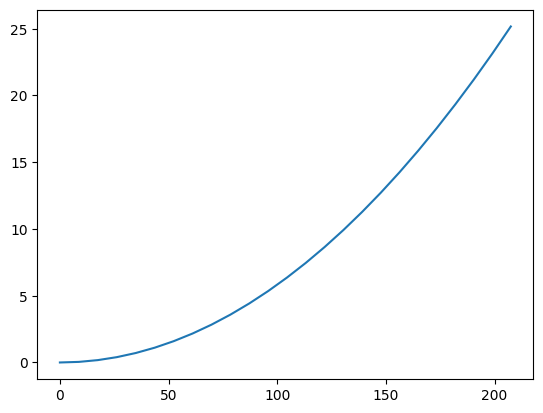

In [66]:
plt.plot(x0, z0-z0[0])
plt.show()

In [67]:
q0=np.zeros(12*N)

In [68]:
theta0 = np.zeros(N)

for i in range(N):
    if i == 0:
        dzdx = (z0[1] - z0[0]) / (x0[1] - x0[0])
    elif i == N-1:
        dzdx = (z0[-1] - z0[-2]) / (x0[-1] - x0[-2])
    else:
        dzdx = (z0[i+1] - z0[i-1]) / (x0[i+1] - x0[i-1])

    theta0[i] = -np.arctan2(dzdx, 1.0)

In [69]:
q0[0*N:1*N] = x0
q0[2*N:3*N] = 0.0
z0=z0-z0[0]
q0[4*N:5*N] = z0

q0[6*N:7*N] = 0.0       # phi
q0[8*N:9*N] = theta0    # theta
q0[10*N:11*N] = 0.0     # psi

In [70]:
# for j in range(1,12):
#     if j==1:
#         q0[(j-1)*N:j*N]=x0
#     elif j==5:
#         q0[(j-1)*N:j*N]=z0

In [71]:
print("\nINITIAL CONSTITUTIVE STRAIN TEST")
φ=q0[6*N:7*N]
θ=q0[8*N:9*N]
ψ=q0[10*N:11*N]
x=q0[0*N:1*N]
y=q0[2*N:3*N]
z=q0[4*N:5*N]
h = delta_x
for j in [1, 5, 10, 15, 20, 24]:

    R = Ret_e_t(
        0.5*(φ[j-1] + φ[j]),
        0.5*(θ[j-1] + θ[j]),
        0.5*(ψ[j-1] + ψ[j])
    )

    rprime = d_s_phi(
        x[j-1], y[j-1], z[j-1],
        x[j],   y[j],   z[j], h
    ).flatten()

    strain = rprime - R @ np.array([1.,0.,0.])

    n = ne(
        x[j-1], y[j-1], z[j-1],
        φ[j-1], θ[j-1], ψ[j-1],
        x[j], y[j], z[j],
        φ[j], θ[j], ψ[j], h
    )

    print(
        j,
        "r' =", rprime,
        "Re1 =", R @ np.array([1.,0.,0.]),
        "strain =", strain,
        "|strain| =", np.linalg.norm(strain),
        "|n| =", np.linalg.norm(n)
    )


INITIAL CONSTITUTIVE STRAIN TEST
1 r' = [0.9999828  0.         0.00507888] Re1 = [0.99997098 0.         0.00761805] strain = [ 1.18209949e-05  0.00000000e+00 -2.53917008e-03] |strain| = 0.0025391975992347608 |n| = 5302659.742696971
5 r' = [0.99895262 0.         0.04566284] Re1 = [0.99895701 0.         0.04566068] strain = [-4.38418789e-06  0.00000000e+00  2.15020147e-06] |strain| = 4.8830799522997785e-06 |n| = 43917.82477960215
10 r' = [0.99537191 0.         0.09605378] Re1 = [0.99537658 0.         0.09604933] strain = [-4.67022067e-06  0.00000000e+00  4.45855498e-06] |strain| = 6.456754102424061e-06 |n| = 44214.42912875691
15 r' = [0.9893221  0.         0.14571735] Re1 = [0.98932724 0.         0.14571074] strain = [-5.13535748e-06  0.00000000e+00  6.60089134e-06] |strain| = 8.36323280158068e-06 |n| = 44651.054365103984
20 r' = [0.98093733 0.         0.19430388] Re1 = [0.98094307 0.         0.19429537] strain = [-5.74325447e-06  0.00000000e+00  8.50726930e-06] |strain| = 1.02644338779

In [72]:
for j in [1, 5, 10, 15, 20, 24]:

    rp = d_s_phi(
        x[j-1], y[j-1], z[j-1],
        x[j], y[j], z[j], h
    ).flatten()

    print(
        j,
        "||r'|| =", np.linalg.norm(rp),
        "strain =", np.linalg.norm(
            rp - Ret_e_t(
                0.5*(φ[j-1]+φ[j]),
                0.5*(θ[j-1]+θ[j]),
                0.5*(ψ[j-1]+ψ[j])
            ) @ np.array([1.,0.,0.])
        )
    )

1 ||r'|| = 0.99999570087872 strain = 0.0025391975992347608
5 ||r'|| = 0.9999957185672164 strain = 4.8830799522997785e-06
10 ||r'|| = 0.9999957796248811 strain = 6.456754102424061e-06
15 ||r'|| = 0.9999958812982629 strain = 8.36323280158068e-06
20 ||r'|| = 0.9999960191621327 strain = 1.0264433877958506e-05
24 ||r'|| = 0.9999961517213078 strain = 0.0024080281733438575


In [73]:
def fun1(x_int,φ,θ,ψ,t):
    
    def fun1_(x_int,φ,θ,ψ,t):
        A=mp*TPL*1/2*(1-x_int)*1/2*(1+x_int)*np.identity(3)
        B=np.zeros((3,3))

        Pi = Πe(φ, θ, ψ)
        Ie = I_e_rho(φ, θ, ψ)
     
        D=1/2*(1-x_int)*1/2*(1+x_int)* Pi.T @ Ie @ Pi
            
        return h/2*np.block([[A, B], [B, D]])
    
    res = np.array([fun1_(xi,φ,θ,ψ,t) for xi in x_int])
    return np.moveaxis(res, 0, -1)


def fun2_1(x_int, x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, h):
    
    def fun2_1_(x_int, x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, h):
        A=1/h*np.identity(3)
        B=np.zeros((3,3))
        C=-1/2*(1+x_int)*S(*d_s_phi(x1, y1, z1, x2, y2, z2, h))
        return h/2*np.block([[A, B], [C, A]])@np.concatenate((np.asarray(ne(x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, h)),
                                                              np.asarray(me(φ1, θ1, ψ1, φ2, θ2, ψ2, h))), axis=None)
    
    res = np.array([fun2_1_(xi, x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, h) for xi in x_int])
    return np.moveaxis(res, 0, -1)

    
def fun2_2(x_int, x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, h):
    
    def fun2_2_(x_int, x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, h):
        A=1/h*np.identity(3)
        B=np.zeros((3,3))
        C=-1/2*(1-x_int)*S(*d_s_phi(x1, y1, z1, x2, y2, z2, h))
        return h/2*np.block([[A, B], [C, A]])@np.concatenate((np.asarray(ne(x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, h)),
                                                              np.asarray(me(φ1, θ1, ψ1, φ2, θ2, ψ2, h))), axis=None)
    
    res = np.array([fun2_2_(xi, x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, h) for xi in x_int])
    return np.moveaxis(res, 0, -1)    

    
def fun3_1(x_int,φ,θ,ψ, dφ, dθ, dψ,t):
    
    def fun3_1_(x_int,φ,θ,ψ, dφ, dθ, dψ,t):
        A=np.zeros(3)  
        B=1/2*(1+x_int)*I_e_rho(φ,θ,ψ)@dΠ(φ, θ, ψ, dφ, dθ, dψ)@np.array([dφ, dθ, dψ])
        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun3_1_(xi,φ,θ,ψ, dφ, dθ, dψ,t) for xi in x_int])
    return np.moveaxis(res, 0, -1)  

    
def fun3_2(x_int,φ,θ,ψ, dφ, dθ, dψ,t):
    
    def fun3_2_(x_int,φ,θ,ψ, dφ, dθ, dψ,t):
        A=np.zeros(3) 
        B=1/2*(1-x_int)*I_e_rho(φ,θ,ψ)@dΠ(φ, θ, ψ, dφ, dθ, dψ)@np.array([dφ, dθ, dψ])
        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun3_2_(xi,φ,θ,ψ, dφ, dθ, dψ,t) for xi in x_int])
    return np.moveaxis(res, 0, -1)    

    
def fun4_1(x_int,φ,θ,ψ, dφ, dθ, dψ,t):
    
    def fun4_1_(x_int,φ,θ,ψ, dφ, dθ, dψ,t):
        A=np.zeros(3)  
        B=1/2*(1+x_int)*S(*(Πe(φ, θ, ψ)@np.array([dφ, dθ, dψ])))@(I_e_rho(φ,θ,ψ)@Πe(φ, θ, ψ)@np.array([dφ, dθ, dψ])).T
        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun4_1_(xi,φ,θ,ψ, dφ, dθ, dψ,t) for xi in x_int])
    return np.moveaxis(res, 0, -1)

    
def fun4_2(x_int,φ,θ,ψ, dφ, dθ, dψ,t):
    
    def fun4_2_(x_int,φ,θ,ψ, dφ, dθ, dψ,t):
        A=np.zeros(3) 
        B=1/2*(1-x_int)*S(*(Πe(φ, θ, ψ)@np.array([dφ, dθ, dψ])))@(I_e_rho(φ,θ,ψ)@Πe(φ, θ, ψ)@np.array([dφ, dθ, dψ])).T
        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun4_2_(xi,φ,θ,ψ, dφ, dθ, dψ,t) for xi in x_int])
    return np.moveaxis(res, 0, -1)    

    
def fun5_1(x_int, li):
    
    def fun5_1_(x_int, li):
        B=np.zeros(3)   
        A=1/2*(1+x_int)*fe_g*li
        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun5_1_(x, li) for x in x_int])
    return np.moveaxis(res, 0, -1)

    
def fun5_2(x_int, li):
    
    def fun5_2_(x_int, li):
        B=np.zeros(3)   
        A=1/2*(1-x_int)*fe_g*li
        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun5_2_(x, li) for x in x_int])
    return np.moveaxis(res, 0, -1)    

    
def fun6_1(x_int,φ,θ,ψ, dx, dy, dz, dφ, dθ, dψ):
    
    def fun6_1_(x_int,φ,θ,ψ, dx, dy, dz, dφ, dθ, dψ):
        A=1/2*(1+x_int)* Ret_e_t(φ,θ,ψ)@f_t_d(dx,dy,dz)
        B=1/2*(1+x_int)* DR@ Πe(φ, θ, ψ)@  np.array([dφ, dθ, dψ])

        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)  
    
    res = np.array([fun6_1_(xi,φ,θ,ψ, dx, dy, dz, dφ, dθ, dψ) for xi in x_int])
    return np.moveaxis(res, 0, -1)


def fun6_2(x_int,φ,θ,ψ, dx, dy, dz, dφ, dθ, dψ):
    
    def fun6_2_(x_int,φ,θ,ψ, dx, dy, dz, dφ, dθ, dψ):
        A=1/2*(1-x_int)* Ret_e_t(φ,θ,ψ)@f_t_d(dx,dy,dz)
        B=1/2*(1-x_int)* DR@ Πe(φ, θ, ψ)@  np.array([dφ, dθ, dψ])

        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun6_2_(xi,φ,θ,ψ, dx, dy, dz, dφ, dθ, dψ) for xi in x_int])
    return np.moveaxis(res, 0, -1)    

    
def fun7_1(x_int,x,y,z):
   
    def fun7_1_(x_int,x,y,z):
        A=1/2*(1+x_int)*sigma(x,y,z)
        B=np.zeros(3) 

        ans=h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)

        return ans
    
    res = np.array([fun7_1_(xi,x,y,z) for xi in x_int])
    return np.moveaxis(res, 0, -1)


def fun7_2(x_int,x,y,z):
   
    def fun7_2_(x_int,x,y,z):
        A=1/2*(1-x_int)*sigma(x,y,z)
        B=np.zeros(3) 

        ans=h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)

        return ans
    
    res = np.array([fun7_2_(xi,x,y,z) for xi in x_int])
    return np.moveaxis(res, 0, -1)    

In [74]:
def body_frame_nu(u_dot_xyz, phi, theta, psi, dphi, dtheta, dpsi):
    """Eq. (64): rotate spatial velocity + convert Euler rates -> body-frame nu."""
    Re_b = Ret_e_t(phi, theta, psi)
    w_e  = Πe(phi, theta, psi) @ np.array([dphi, dtheta, dpsi])   # Eq. (100)
    nu_lin = Re_b.T @ np.asarray(u_dot_xyz)
    nu_ang = Re_b.T @ w_e
    return np.concatenate([nu_lin, nu_ang])

In [75]:
def static_solution(Q, T): 
    x, y, z = Q[0:N], Q[1*N:2*N], Q[2*N:3*N]
    φ, θ, ψ = Q[3*N:4*N], Q[4*N:5*N], Q[5*N:6*N]
    
    f2 = []
    f5 = []
    f7 = []
    f8 = []
   
    for j in range(N):
        if j == N-1:
            g_eta = restoring_vector_body(
                phi(x[j], y[j], z[j]), 
                Ret_e_t(φ[j], θ[j], ψ[j]), 
                VesselRestoringParams(
                    A_wp = A_wp,     
                    rho_w = qw,    
                    g = 9.81,       
                    z_eq = z0[-1],  
                    m_V = mn,       
                    GM_L = L,       
                    GM_T = 2*Yg,        
                )
            )
            
            res_f2 = integrate.fixed_quad(lambda x_int: fun2_1(x_int, x[j-1], y[j-1], z[j-1], φ[j-1], θ[j-1], ψ[j-1], x[j], y[j], z[j], φ[j], θ[j], ψ[j], h), -1.0, 1.0, n=1)[0]
            res_f5 = integrate.fixed_quad(lambda x_int: fun5_1(x_int, 1), -1.0, 1.0, n=2)[0]
            
            f2.append(res_f2)
            f5.append(res_f5)
            f7.append(np.zeros(6))
            
            J = np.block([
                [Ret_e_t(φ[j], θ[j], ψ[j]).T, np.zeros((3, 3))],
                [np.zeros((3, 3)), Ret_e_t(φ[j], θ[j], ψ[j]).T @ Πe(φ[j], θ[j], ψ[j])]
            ])
            F_body = (g_eta - np.array([Fx_0, 0, 0, 0, 0, 0]))
            F_generalized = J.T @ F_body
            f8.append(F_generalized.flatten())
        elif j==0:
            f2.append(np.zeros(6))
            f5.append(np.zeros(6))
            res_f7 = integrate.fixed_quad(lambda x_int: fun7_2(x_int, x[j],y[j],z[j]), -1.0, 1.0, n=2)[0]
            f7.append(res_f7)
            f8.append(np.zeros(6)) 
        else:
            res_f2 = (integrate.fixed_quad(lambda x_int: fun2_1(x_int, x[j-1], y[j-1], z[j-1], φ[j-1], θ[j-1], ψ[j-1], x[j], y[j], z[j], φ[j], θ[j], ψ[j], h), -1.0, 1.0, n=1)[0]
                      + integrate.fixed_quad(lambda x_int: fun2_2(x_int, x[j], y[j], z[j], φ[j], θ[j], ψ[j], x[j+1], y[j+1], z[j+1], φ[j+1], θ[j+1], ψ[j+1], h), -1.0, 1.0, n=1)[0])
            
            res_f5 = (integrate.fixed_quad(lambda x_int: fun5_1(x_int, 1), -1.0, 1.0, n=2)[0]
                      + integrate.fixed_quad(lambda x_int: fun5_2(x_int, 1), -1.0, 1.0, n=2)[0])
            f2.append(res_f2)
            f5.append(res_f5)

            f7.append(np.zeros(6))
            f8.append(np.zeros(6)) 

    f2 = np.array(f2) 
    f5 = np.array(f5) 
    f7 = np.array(f7)
    f8 = np.array(f8)
    
    f_sum = (f2 + f5 + f7 + f8)
        
    return f_sum.flatten()

In [76]:
T_1 = MyTime()

In [77]:
q0_stat=np.concatenate((q0[0:N],q0[2*N:3*N],q0[4*N:5*N],q0[6*N:7*N],q0[8*N:9*N],q0[10*N:11*N]))

In [78]:
root_ = root(static_solution, q0_stat, 
             method='lm', 
             args=(T_1,))

In [79]:
root_

 message: The relative error between two consecutive iterates is at most 0.000000
 success: True
  status: 2
     fun: [ 0.000e+00  0.000e+00 ... -1.853e-03 -8.292e-04]
       x: [-2.326e+00  6.357e+00 ... -1.145e-01 -1.170e-01]
   cov_x: [[ 4.272e+14  4.307e+14 ... -3.104e+13 -3.188e+13]
           [ 4.307e+14  4.341e+14 ... -3.132e+13 -3.217e+13]
           ...
           [-3.104e+13 -3.132e+13 ...  2.736e+12  2.799e+12]
           [-3.188e+13 -3.217e+13 ...  2.799e+12  2.863e+12]]
  method: lm
    nfev: 7263
    fjac: [[-7.044e+10  0.000e+00 ...  9.961e-01 -3.193e-03]
           [ 0.000e+00 -1.144e+10 ...  0.000e+00  0.000e+00]
           ...
           [ 0.000e+00  0.000e+00 ... -8.784e-08 -7.683e-01]
           [ 0.000e+00 -4.349e+07 ...  3.805e-08 -4.838e-08]]
    ipvt: [125 128 ...  59   1]
     qtf: [ 2.058e-03  1.687e-03 ... -4.500e-13  5.347e-13]

In [80]:
x0_, y0_, z0_ = root_.x[:N],root_.x[1*N:2*N], root_.x[2*N:3*N]

In [81]:
q0 = np.concatenate((root_.x[:N],
      np.zeros(N),
      root_.x[1*N:2*N], 
      np.zeros(N),
      root_.x[2*N:3*N],
      np.zeros(N),
      root_.x[3*N:4*N],
      np.zeros(N),
      root_.x[4*N:5*N],
      np.zeros(N),
      root_.x[5*N:6*N],
      np.zeros(N)))                                    # start from static solution

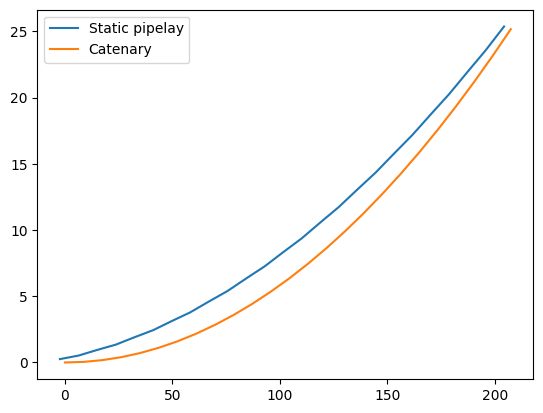

In [82]:
plt.plot(x0_, z0_, label = "Static pipelay")
plt.plot(x0, z0, label = "Catenary")
plt.legend()
plt.show()

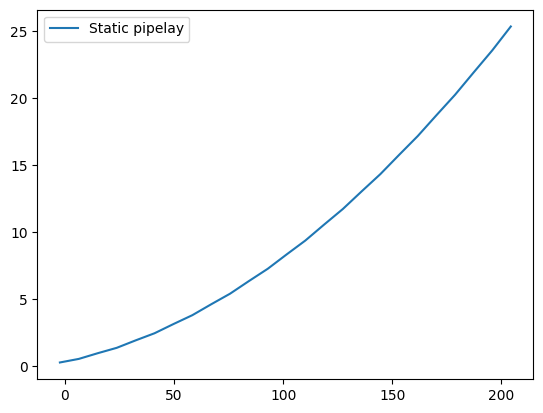

In [83]:
plt.plot(x0_, z0_, label = "Static pipelay")
plt.legend()
plt.show()

### Dynamic Simulation

In [84]:
def dynamic_func(t, Q, T, z0):
        
    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
        
    f1=[]
    f2=[]
    f3=[] 
    f4=[]
    f5=[]
    f6=[]
    f7=[]
    f8=[]
    
    for j in range(N):
        
        if j == N-1:
            nu = body_frame_nu(np.array([dx[j], dy[j], dz[j]]), φ[j], θ[j], ψ[j], dφ[j], dθ[j], dψ[j])
            C_nu = T.CRB(T.MRB, nu) + T.CA(T.MA, nu)
            g_eta = restoring_vector_body(phi(x[j],y[j],z[j]), Ret_e_t(φ[j], θ[j], ψ[j]), 
                                  VesselRestoringParams(
                                                        A_wp = A_wp,     # m^2, water plane area
                                                        rho_w = qw,    # kg/m^3
                                                        g = 9.81,       # m/s^2
                                                        z_eq = z0[-1],        # equilibrium heave [m]
                                                        m_V = mn,       # kg, vessel mass
                                                        GM_L = L,       # m, longitudinal metacentric height
                                                        GM_T = 2*Yg,        # m, transversal metacentric height
                                                    ))
    
            D_nu = compute_damping(T.MRB, g_eta, T.r_g, 20, 100, 50)

            
            J = np.block([
                [Ret_e_t(φ[j],θ[j],ψ[j]).T, np.zeros((3,3))],
                [np.zeros((3,3)), Ret_e_t(φ[j],θ[j],ψ[j]).T @ Πe(φ[j],θ[j],ψ[j])]
            ])

            M_generalized = J.T @ T.M @ J
            
            f1.append(integrate.fixed_quad(lambda x_int: fun1(x_int, φ[j], θ[j], ψ[j],t), -1.0, 1.0, n=2)[0] + M_generalized )
            f2.append(integrate.fixed_quad(lambda x_int: fun2_1(x_int, x[j-1],y[j-1],z[j-1],φ[j-1],θ[j-1],ψ[j-1],x[j],y[j],z[j],φ[j],θ[j],ψ[j],h), -1.0,1.0,n=1)[0])
            f3.append(integrate.fixed_quad(lambda x_int: fun3_1(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j],t), -1.0, 1.0, n=2)[0])
            f4.append(integrate.fixed_quad(lambda x_int: fun4_1(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j],t), -1.0, 1.0, n=2)[0])
            f5.append(integrate.fixed_quad(lambda x_int: fun5_1(x_int, 1), -1.0, 1.0, n=2)[0])
            f6.append((integrate.fixed_quad(lambda x_int: fun6_1(x_int, φ[j],θ[j],ψ[j],dx[j],dy[j],dz[j],dφ[j],dθ[j],dψ[j]), -1.0, 1.0, n=2)[0]))
            f7.append(np.zeros(6))

            F_body = (
                    g_eta
                    + (C_nu + D_nu) @ nu
                    - np.array([Fx_0,0,0,0,0,0])
                )
            F_generalized = J.T @ F_body
            f8.append(F_generalized)
        elif j==0:
            f1.append(integrate.fixed_quad(lambda x_int: fun1(x_int, φ[j], θ[j], ψ[j],t), -1.0, 1.0, n=2)[0])
            f2.append(np.zeros(6))
            f3.append(np.zeros(6))
            f4.append(np.zeros(6))
            f5.append(np.zeros(6))
            res_f7 = integrate.fixed_quad(lambda x_int: fun7_2(x_int, x[j],y[j],z[j]), -1.0, 1.0, n=2)[0]
            f6.append(np.zeros(6))
            f7.append(res_f7)
            f8.append(np.zeros(6)) 
        else:
            f1.append(integrate.fixed_quad(lambda x_int: fun1(x_int, φ[j], θ[j], ψ[j],t), -1.0, 1.0, n=2)[0])
            f2.append(integrate.fixed_quad(lambda x_int: fun2_1(x_int, x[j-1],y[j-1],z[j-1],φ[j-1],θ[j-1],ψ[j-1],x[j],y[j],z[j],φ[j],θ[j],ψ[j],h), -1.0,1.0,n=1)[0]
                     +integrate.fixed_quad(lambda x_int: fun2_2(x_int, x[j],y[j],z[j],φ[j],θ[j],ψ[j],x[j+1],y[j+1],z[j+1],φ[j+1],θ[j+1],ψ[j+1],h), -1.0,1.0,n=1)[0])
            f3.append(integrate.fixed_quad(lambda x_int: fun3_1(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j],t), -1.0, 1.0, n=2)[0]
                     +integrate.fixed_quad(lambda x_int: fun3_2(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j],t), -1.0, 1.0, n=2)[0])
            f4.append(integrate.fixed_quad(lambda x_int: fun4_1(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j],t), -1.0, 1.0, n=2)[0]
                     +integrate.fixed_quad(lambda x_int: fun4_2(x_int, φ[j],θ[j],ψ[j],dφ[j],dθ[j],dψ[j],t), -1.0, 1.0, n=2)[0])
            f5.append(integrate.fixed_quad(lambda x_int: fun5_1(x_int, 1), -1.0, 1.0, n=2)[0]
                     +integrate.fixed_quad(lambda x_int: fun5_2(x_int, 1), -1.0, 1.0, n=2)[0])
            f6.append(integrate.fixed_quad(lambda x_int: fun6_1(x_int, φ[j],θ[j],ψ[j],dx[j],dy[j],dz[j],dφ[j],dθ[j],dψ[j]), -1.0, 1.0, n=2)[0]
                     +integrate.fixed_quad(lambda x_int: fun6_2(x_int, φ[j],θ[j],ψ[j],dx[j],dy[j],dz[j],dφ[j],dθ[j],dψ[j]), -1.0, 1.0, n=2)[0])
            f7.append(np.zeros(6))
            f8.append(np.zeros(6))
         
        if t>0.01 and j>0:
            ax=np.linalg.inv(Ret_e_t(φ[j],θ[j],ψ[j]))@ ne(x[j-1], y[j-1], z[j-1], φ[j-1], θ[j-1], ψ[j-1],x[j], y[j], z[j], φ[j], θ[j], ψ[j],h).T

            T.top_tension=max(T.top_tension, ax[0])            

            ben0=np.linalg.inv(Ret_e_t(φ[j],θ[j],ψ[j])) @ me( φ[j-1], θ[j-1], ψ[j-1], φ[j],θ[j],ψ[j],h).T
            ben=np.max(ben0[1:])

            I=3.14*(d0**4-dI**4)/64
            strain=np.max(ben)*d0/(2*E*I)    

            T.sagbend_strain=max(T.sagbend_strain, strain)    
    

    f1 = np.array(f1)
    f1 = np.stack(f1, axis=0)
    f2=np.vstack(f2) 
    f3=np.vstack(f3)
    f4=np.vstack(f4) 
    f5=np.vstack(f5)
    f6=np.vstack(f6) 
    f7=np.vstack(f7)
    f8=np.vstack(f8)
    
    ddx=np.zeros(N)
    ddy=np.zeros(N)
    ddz=np.zeros(N)
    ddφ=np.zeros(N)
    ddθ=np.zeros(N)
    ddψ=np.zeros(N)
  
    f_sum = -(f2 + f3 + f4 + f5 + f6 + f8)
    R_64 = f_sum.astype(np.float64, copy=False).flatten()
    
    beta_rayleigh = 1e-4
    if hasattr(T, 'last_X') and T.last_X is not None:
        R_64 -= beta_rayleigh * T.last_X.flatten()
    
    f1_64 = [block.astype(np.float64, copy=False) for block in f1]
    M_sparse = sp.block_diag(f1_64, format='csc')
    
    solve_sparse = spla.splu(M_sparse).solve
    X_raw = solve_sparse(R_64)
    
    X = X_raw.reshape(N, 6)

    ddx, ddy, ddz, ddφ, ddθ, ddψ = X.T  

    ans=np.concatenate([dx, ddx, 
                        dy, ddy,  
                        dz, ddz, 
                        dφ, ddφ,  
                        dθ, ddθ, 
                        dψ, ddψ,  
                       ], axis=0)


        
    if t>T.progression[0]:
        
        T.progression.pop(0)
        print('Physical time: ', t, ' Iteration wall-clock time: ', datetime.now() - T.wall_clock , flush=True)
        T.wall_clock = datetime.now() 
    
    T.my_iter+=1 

    if np.any(np.abs(ans) > 1e6) or np.any(np.isnan(ans)):
        print(f"\n!!! CRITICAL SYSTEM EXPLOSION AT t = {t} !!!")
        
        bad_idx = np.where((np.abs(ans) > 1e10) | (np.isnan(ans)))[0]
        for idx in bad_idx:
            print(f"Index Q[{idx}] returned an invalid value: {ans[idx]}")
               
        print("Right-hand side vector R (first 20 elements):", f_sum[:20])
        M_global = sp.block_diag(f1_64, format='csc')
        M = M_global.toarray()
        print(
            "global condition estimate:",
            np.linalg.cond(M)
        )
        
        print("symmetry error:",
              np.linalg.norm(M - M.T) / np.linalg.norm(M))
        
        eig = np.linalg.eigvalsh(0.5*(M + M.T))
        
        print("min eigenvalue:", eig.min())
        print("max eigenvalue:", eig.max())

        print("max dx :", np.max(np.abs(dx)))
        print("max dy :", np.max(np.abs(dy)))
        print("max dz :", np.max(np.abs(dz)))
        print("max dphi :", np.max(np.abs(dφ)))
        print("max dtheta :", np.max(np.abs(dθ)))
        print("max dpsi :", np.max(np.abs(dψ)))
        
        print("max ddx :", np.max(np.abs(ddx)))
        print("max ddy :", np.max(np.abs(ddy)))
        print("max ddz :", np.max(np.abs(ddz)))
        print("max ddphi :", np.max(np.abs(ddφ)))
        print("max ddtheta :", np.max(np.abs(ddθ)))
        print("max ddpsi :", np.max(np.abs(ddψ)))
        
        raise ValueError("Simulation aborted due to Inf/NaN generation.")

    return ans 

In [85]:
T_3 = MyTime()

In [86]:
startTime1 = datetime.now()
us_ = solve_ivp(dynamic_func, 
                tspan, 
                q0, 
                method='BDF',
                args=(T_3,z0))
print(datetime.now() - startTime1)

Physical time:  0.7748673457463447  Iteration wall-clock time:  0:00:00.052541
Physical time:  1.0150265665551679  Iteration wall-clock time:  0:00:07.297792
Physical time:  2.9818580428432235  Iteration wall-clock time:  0:00:00.446861
Physical time:  6.0056509292273175  Iteration wall-clock time:  0:00:00.148651
Physical time:  6.0056509292273175  Iteration wall-clock time:  0:00:00.080639
Physical time:  9.029443815611412  Iteration wall-clock time:  0:00:00.052187
Physical time:  9.029443815611412  Iteration wall-clock time:  0:00:00.025635
Physical time:  20.0  Iteration wall-clock time:  0:00:00.227445
Physical time:  20.0  Iteration wall-clock time:  0:00:00.069188
0:00:08.485619


### Results

In [87]:
# number of iterations
T_3.my_iter

325

In [88]:
# max axial tension
T_3.top_tension

1526602.4992507545

In [89]:
# max bending strain
T_3.sagbend_strain

0.010721679019951046

In [90]:
fin=us_

In [91]:
fin

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  3.339e-02  6.679e-02  1.996e-01  3.324e-01
             6.737e-01  1.015e+00  1.998e+00  2.982e+00  6.006e+00
             9.029e+00  2.000e+01]
        y: [[-2.326e+00 -2.326e+00 ... -2.326e+00 -2.326e+00]
            [ 6.357e+00  6.357e+00 ...  6.357e+00  6.357e+00]
            ...
            [ 0.000e+00 -3.823e-10 ... -9.344e-11 -1.388e-11]
            [ 0.000e+00  6.772e-15 ...  1.503e-12  9.637e-12]]
      sol: None
 t_events: None
 y_events: None
     nfev: 24
     njev: 1
      nlu: 6

In [92]:
t=fin.t
fin=fin.y.T

In [93]:
t.shape, fin.shape

((12,), (12, 300))

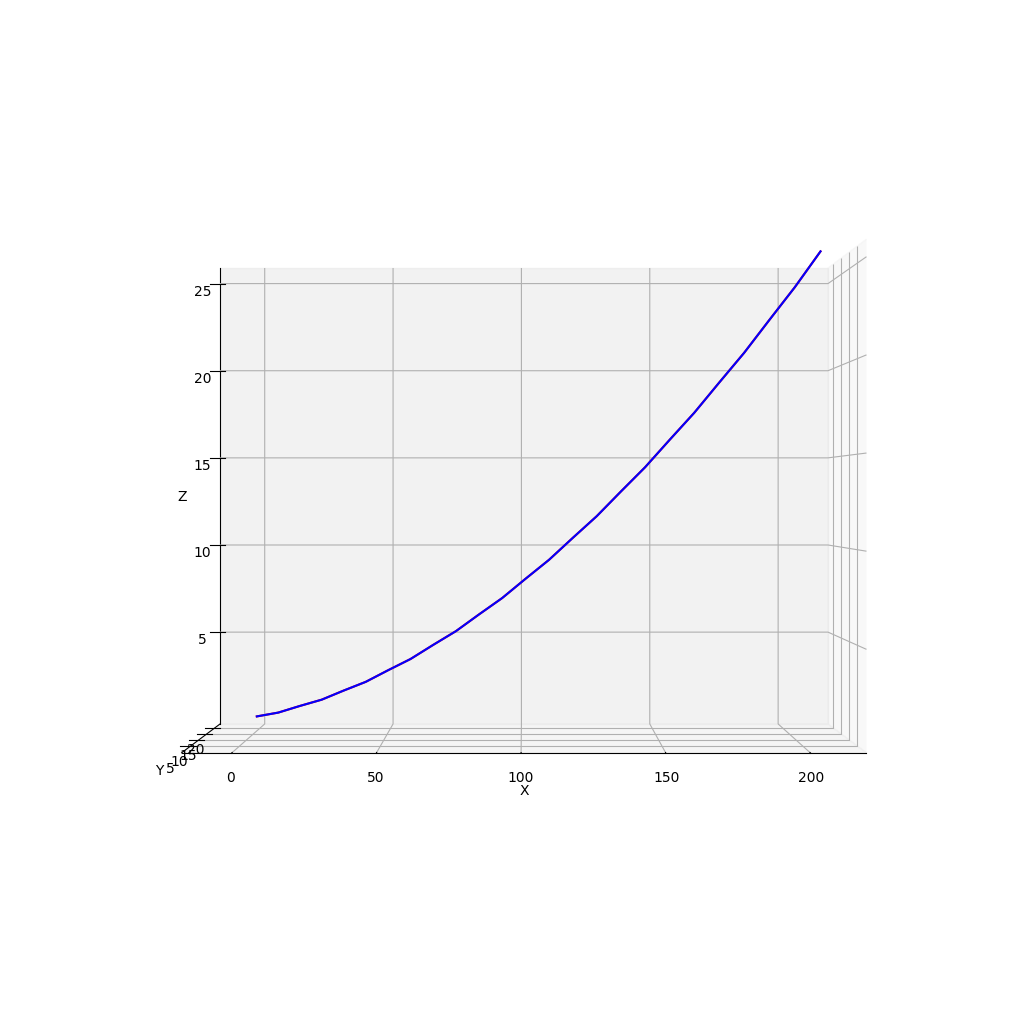

In [94]:
fig=plt.figure(figsize=(13,13))
ax = fig.add_subplot(projection = '3d')

X0=fin[0,[i for i in range(0,N)]]
Y0=fin[0,[i for i in range(2*N,3*N)]]
Z0=fin[0,[i for i in range(4*N,5*N)]]

j=-1
X=fin[j,[i for i in range(0,N)]]
Y=fin[j,[i for i in range(2*N,3*N)]]
Z=fin[j,[i for i in range(4*N,5*N)]]

num_true_pts = 200
tck, u = interpolate.splprep([X,Y,Z], s=2)
u_fine = np.linspace(0,1,num_true_pts)
x_fine, y_fine, z_fine = interpolate.splev(u_fine, tck)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.plot(X0,Y0,Z0, color='r')
ax.plot(X,Y,Z, color='b')
ax.view_init(0,-90)
plt.show()

In [95]:
X,Y,Z

(array([ -2.32585503,   6.35692334,  15.03558411,  23.7125097 ,
         32.38338323,  41.05256846,  49.71383737,  58.37345953,
         67.02336947,  75.67166899,  84.30852699,  92.9438058 ,
        101.5659786 , 110.18659841, 118.7925108 , 127.39689148,
        135.98502468, 144.5716426 , 153.14053267, 161.70791911,
        170.25615535, 178.80289489, 187.3291183 , 195.85384731,
        204.35674907]),
 array([22.11881918, 21.26992028, 20.40833476, 19.55377056, 18.68732713,
        17.82783866, 16.9572424 , 16.09353276, 15.21945242, 14.35218862,
        13.47525837, 12.60507311, 11.72589421, 10.8533875 ,  9.9725299 ,
         9.0982707 ,  8.21627454,  7.34080221,  6.4581793 ,  5.58200506,
         4.69924022,  3.82284849,  2.94040086,  2.0642506 ,  1.18255491]),
 array([ 0.2539911 ,  0.52159273,  0.94719255,  1.34819906,  1.90549108,
         2.43832474,  3.12572549,  3.78880348,  4.60472632,  5.39646267,
         6.33931955,  7.25812689,  8.32632999,  9.3706212 , 10.56258443,
      

In [96]:
X0,Y0,Z0

(array([ -2.32585503,   6.35692334,  15.03558411,  23.7125097 ,
         32.38338323,  41.05256846,  49.71383737,  58.37345953,
         67.02336947,  75.67166899,  84.30852699,  92.9438058 ,
        101.5659786 , 110.18659842, 118.7925108 , 127.39689148,
        135.98502469, 144.57164261, 153.14053268, 161.70791911,
        170.25615535, 178.80289489, 187.32911831, 195.85384731,
        204.35674908]),
 array([22.11881918, 21.26992028, 20.40833477, 19.55377057, 18.68732714,
        17.82783867, 16.95724241, 16.09353277, 15.21945243, 14.35218864,
        13.47525839, 12.60507312, 11.72589422, 10.85338752,  9.97252992,
         9.09827072,  8.21627456,  7.34080223,  6.45817933,  5.58200508,
         4.69924024,  3.82284851,  2.94040089,  2.06425063,  1.18255494]),
 array([ 0.2539911 ,  0.52159273,  0.94719255,  1.34819906,  1.90549108,
         2.43832474,  3.12572549,  3.78880348,  4.60472632,  5.39646267,
         6.33931955,  7.25812689,  8.32632999,  9.3706212 , 10.56258443,
      

In [97]:
us=fin.T

In [98]:
us.shape

(300, 12)

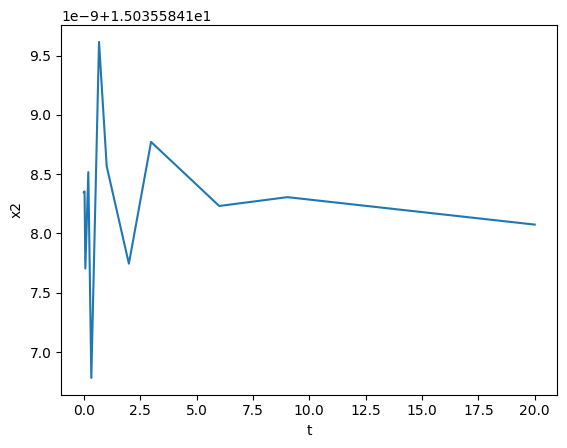

In [99]:
plt.plot(t,us.T[:,2],'-')
plt.xlabel('t')
plt.ylabel('x2')
plt.show()

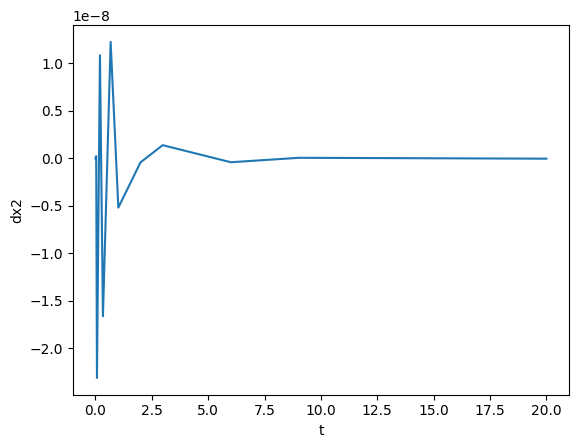

In [100]:
plt.plot(t,us.T[:,N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dx2')
plt.show()

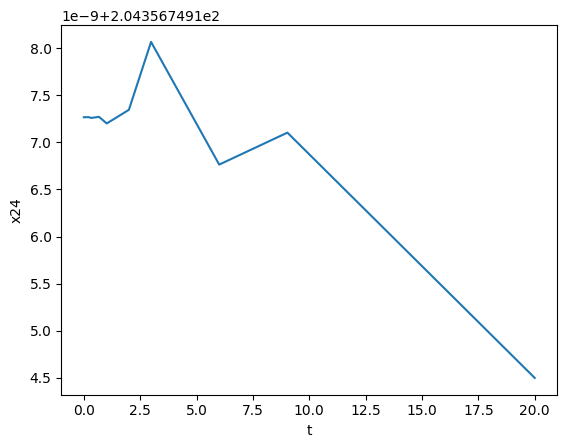

In [101]:
plt.plot(t,us.T[:,N-1] ,'-')
plt.xlabel('t')
plt.ylabel('x{}'.format(N-1))
plt.show()

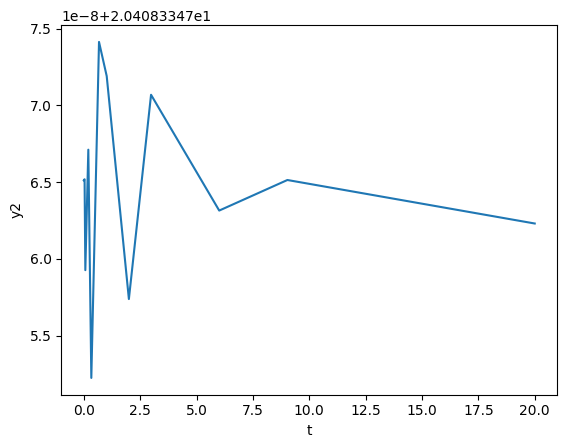

In [102]:
plt.plot(t,us.T[:,2*N +2] ,'-')
plt.xlabel('t')
plt.ylabel('y2')
plt.show()

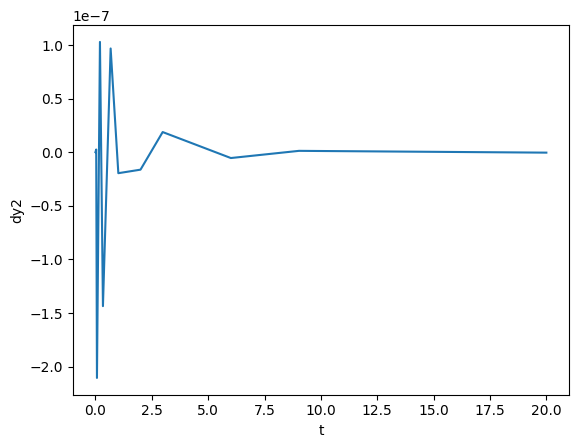

In [103]:
plt.plot(t,us.T[:,3*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dy2')
plt.show()

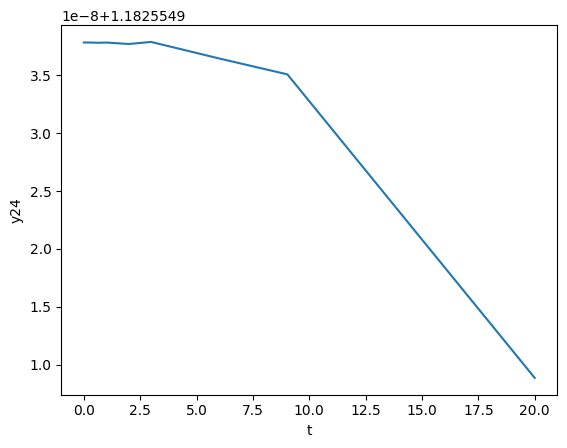

In [104]:
plt.plot(t,us.T[:,2*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('y{}'.format(N-1))
plt.show()

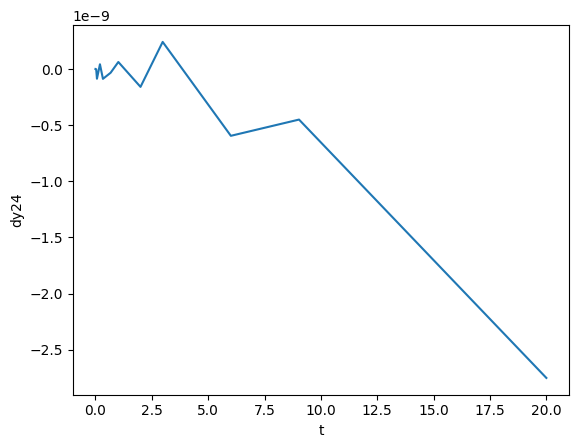

In [105]:
plt.plot(t,us.T[:,3*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('dy{}'.format(N-1))
plt.show()

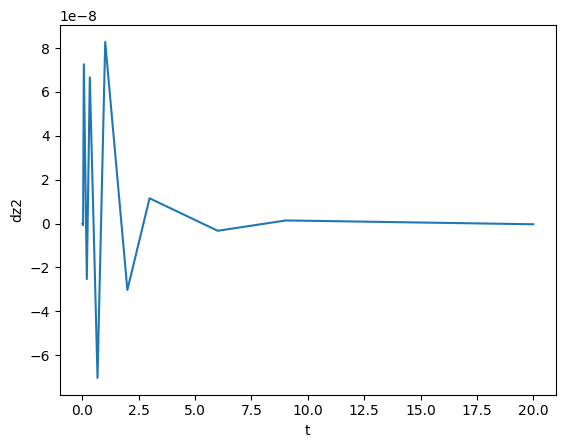

In [106]:
plt.plot(t,us.T[:,5*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dz2')
plt.show()

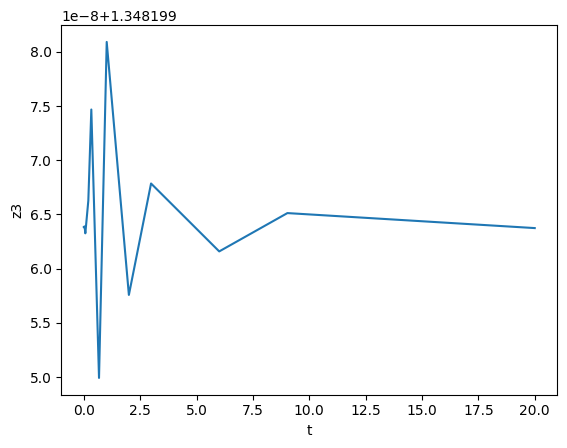

In [107]:
plt.plot(t,us.T[:,4*N+3] ,'-')
plt.xlabel('t')
plt.ylabel('z3')
plt.show()

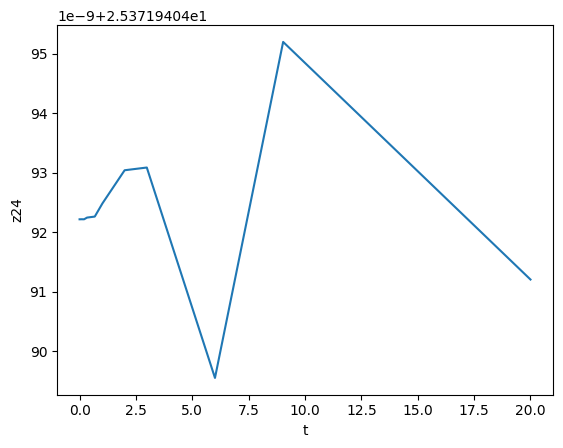

In [108]:
plt.plot(t,us.T[:,4*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('z{}'.format(N-1))
plt.show()

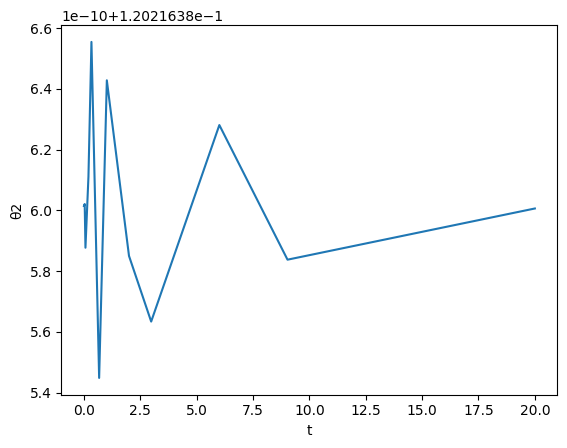

In [109]:
plt.plot(t,us.T[:,8*N+2],'-')
plt.xlabel('t')
plt.ylabel('θ2')
plt.show()

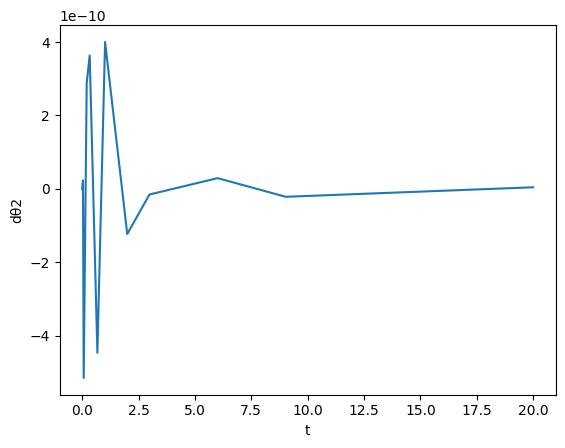

In [110]:
plt.plot(t,us.T[:,9*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dθ2')
plt.show()

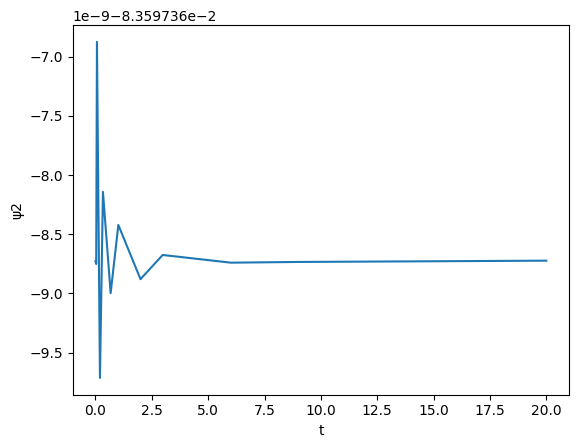

In [111]:
plt.plot(t,us.T[:,10*N+2],'-')
plt.xlabel('t')
plt.ylabel('ψ2')
plt.show()

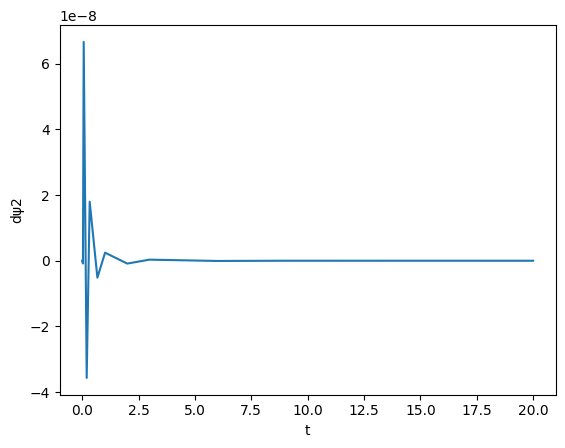

In [112]:
plt.plot(t,us.T[:,11*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dψ2')
plt.show()

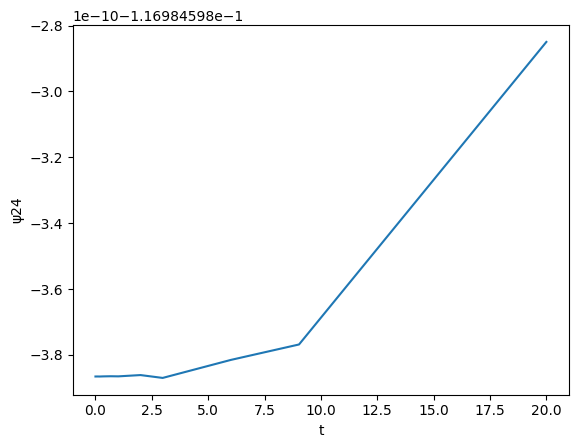

In [113]:
plt.plot(t,us.T[:,10*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('ψ{}'.format(N-1))
plt.show()

In [114]:
X010=us.T[:,0*N:1*N]

In [115]:
Y010=us.T[:,2*N:3*N]

In [116]:
Z010=us.T[:,4*N:5*N]

In [117]:
# simulation = np.stack([X010,Y010,Z010],axis=2) 

# FPS = 5                      
# frame_duration = 1000 / FPS

# frames = []
# for t in range(simulation.shape[0]):
#     x = simulation[t,:,0]
#     y = simulation[t,:,1]
#     z = simulation[t,:,2]

#     frames.append(go.Frame(
#         data=[
#             go.Scatter3d(
#                 x=x, y=y, z=z,
#                 mode="lines+markers",
#                 marker=dict(size=5, color=list(range(12)), colorscale="Viridis"),
#                 line=dict(width=4)
#             )
#         ],
#         name=f"t={t}"
#     ))

# # First frame
# x0, y0, z0 = simulation[0,:,0], simulation[0,:,1], simulation[0,:,2]

# fig = go.Figure(
#     data=[go.Scatter3d(x=x0, y=y0, z=z0, mode="lines+markers")],
#     frames=frames
# )

# # Animation controls
# fig.update_layout(
#     title="Pipeline Simulation ",
#     scene=dict(
#         xaxis_title="X",
#         yaxis_title="Y",
#         zaxis_title="Z",
#         xaxis=dict(range=[0, 400]),
#         yaxis=dict(range=[-50, 50]),
#         zaxis=dict(range=[0, 100]),
#         aspectmode="data",
       
#     ),
#     updatemenus=[{
#         "type": "buttons",
#         "buttons": [
#             {
#                 "label": "Play",
#                 "method": "animate",
#                 "args": [None, {"frame": {"duration": frame_duration, "redraw": True}}]
#             },
#             {
#                 "label": "Pause",
#                 "method": "animate",
#                 "args": [[None], {"frame": {"duration": 0}}]
#             }
#         ]
#     }]
# )

# fig.show()